<a href="https://colab.research.google.com/github/mvlier/topapprox/blob/main/notebook/Reproducing_paper_examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install required packages (only if missing)

This notebook reproduces the paper examples.


In [1]:
import importlib.util
import subprocess
import sys

def ensure_package(module_name, pip_spec):
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {pip_spec} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", pip_spec])
    else:
        print(f"{module_name} already installed")

ensure_package('topapprox', 'topapprox')
ensure_package('cripser', 'cripser')
ensure_package('persim', 'persim')


topapprox already installed
cripser already installed
persim already installed


**BEWARE:** Some cells might show an error when running for the first time. In that case running that cell one more time should resolve the problem.

In [2]:
import topapprox as ta
import cripser
import persim
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import sys,os

import warnings
warnings.filterwarnings("ignore")

# Example V.1 (1D signal)

Text(0.5, 1.0, '0-LPF eps=2.4')

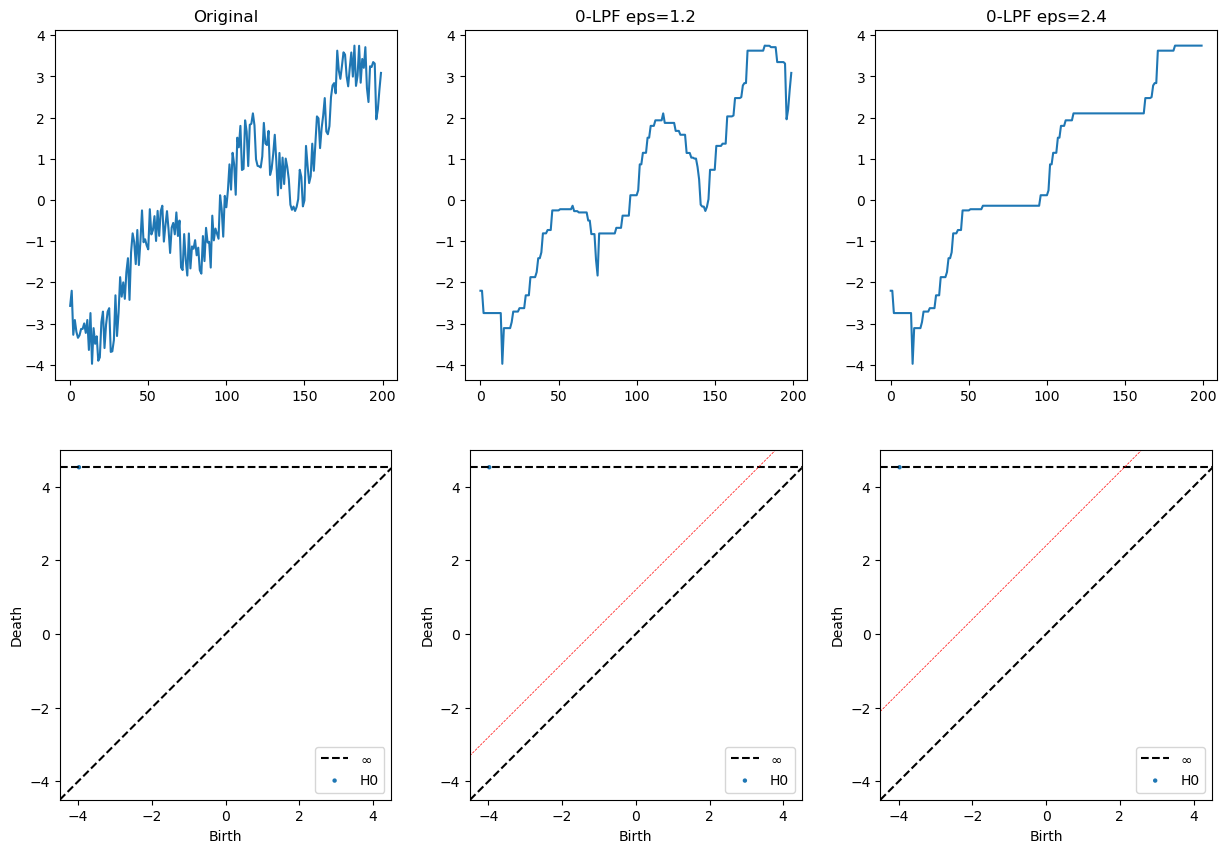

In [3]:
##################
# Creating Signal#
##################

m=200 # resolution
noise = 0.7 # noise level
s=1.2 ## life threshold = simplification strength

# create a sample signal
y, x = np.mgrid[0:1, -10:10:m*1j]
img = np.sin(x)+0.3*x
clean = img.copy().ravel()
img_original = img.copy()
np.random.seed(1)
img += np.random.uniform(-noise,noise,img.shape)
sig = img.copy().ravel()

#################################
# Computing and plotting results#
#################################

fig, axs = plt.subplots(2,3,figsize=(15,10))

# original signal and persistence
axs[0,0].plot(img.ravel())
uf = ta.ImageFilter(img)
# try:
#     newimg = uf.low_pers_filter(epsilon=0)
# except:
#     pass
newimg = uf.low_pers_filter(epsilon=0)
PD = cripser.computePH(newimg)
PD = [PD[PD[:,0]==i,1:3] for i in range(2)]
persim.plot_diagrams(PD,labels=["H0"],size=10,ax=axs[1,0], xy_range = [-4.5,4.5,-4.5,5])
#axs[1,0].plot([-5,5], [-5+s,5+s], '--', linewidth=0.5, c="r")
axs[0,0].set_title(f'Original')


s=1.2
# lpf_0 with eps = 1.2
img2 = uf.low_pers_filter(epsilon=s)
axs[0,1].plot(img2.ravel(), label="Filtered function")
#axs[0,1].plot(img_original.ravel(), label="Trend")
#axs[0,1].legend(loc='lower right')
uf2 = ta.ImageFilter(img2)
newimg = uf.low_pers_filter(epsilon=s)
PD = cripser.computePH(newimg)
PD = [PD[PD[:,0]==i,1:3] for i in range(2)]
persim.plot_diagrams(PD,labels=["H0"],size=10,ax=axs[1,1], xy_range = [-4.5,4.5,-4.5,5])
axs[1,1].plot([-5,5], [-5+s,5+s], '--', linewidth=0.5, c="r")
axs[0,1].set_title(f'0-LPF eps={s}')


s = 2.4
# lpf_0 with eps = 2.4
img2 = uf.low_pers_filter(epsilon=s)
axs[0,2].plot(img2.ravel())
uf2 = ta.ImageFilter(img2)
newimg = uf.low_pers_filter(epsilon=s)
PD = cripser.computePH(newimg)
PD = [PD[PD[:,0]==i,1:3] for i in range(2)]
persim.plot_diagrams(PD,labels=["H0"],size=10,ax=axs[1,2],xy_range = [-4.5,4.5,-4.5,5] )
axs[1,2].plot([-5,5], [-5+s,5+s], '--', linewidth=0.5, c="r")
axs[0,2].set_title(f'0-LPF eps={s}')

# plt.savefig('1D-toy-example.pdf')

# Example V.2 (2D signal)

In [4]:
import topapprox as ta
import cripser
import persim
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import sys,os

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Defining the scalar field to be used in the example
def scalar_field(x,y):
    np.random.seed(0)
    M = 300
    a = np.random.rand(M, 2)*8 + 1
    c = np.random.rand(M)*0.3 + 0.1
    b = 100
    m = c.size
    result = 0
    for i in range(m):
        result += 1 / (b*(x - a[i][0])**2 + b*(y - a[i][1])**2 + c[i])

    a = np.random.rand(M, 2)*8 + 1
    c = np.random.rand(M)*0.3 + 0.1
    m = c.size
    result2 = 0
    for i in range(m):
        result2 += 1 / (b*(x - a[i][0])**2 + b*(y - a[i][1])**2 + c[i])

    Z = result - result2
    Z2 = (x-5)**2 + 3*(y-5)**2
    Z = Z + Z2

    return Z

x = np.linspace(0, 10, 500)
y = np.linspace(0, 10, 500)
X, Y = np.meshgrid(x, y)
surface = scalar_field(X, Y)

In [6]:
# 3D plot settings for better visualization
def plot3D(M, *, with_titles=False, title=None, vmin=None, vmax=None):
    x = np.linspace(0, 500, M.shape[1])  # X-coordinates
    y = np.linspace(0, 500, M.shape[0])  # Y-coordinates
    X, Y = np.meshgrid(x, y)  # Create the meshgrid for X and Y

    # Plot the matrix M in 3D
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Use plot_surface to plot the matrix M
    ax.plot_surface(X, Y, M, cmap='viridis', vmin=vmin, vmax=vmax)

    # Change the perspective
    ax.view_init(elev=10, azim=20)


    # ax.set_ylim(-5,5)
    ax.set_zlim(-10,25)
    # ax.set_xlim(-10,2)

    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

    # x = np.linspace(0, 500, M.shape[1])  # X-coordinates
    # y = np.linspace(0, 500, M.shape[0])  # Y-coordinates
    # X, Y = np.meshgrid(x, y)  # Create the meshgrid for X and Y
    # X, Y = np.meshgrid(x, y)  # Create the meshgrid for X and Y
    ax.plot_surface(X[:, -10:], Y[:, -10:], M[:, -10:], color='red', vmin=vmin, vmax=vmax)
    ax.plot_surface(X[-5:, :], Y[-5:, :], M[-5:, :], color='blue', vmin=vmin, vmax=vmax)
    ax.plot_surface(X[:, :10], Y[:, :10], M[:, :10]+0.5, color='red', vmin=vmin, vmax=vmax)
    ax.plot_surface(X[:5, :], Y[:5, :], M[:5, :]+0.5, color='blue', vmin=vmin, vmax=vmax)

    # ax.grid(False)
    # ax.axis('off')

    if with_titles:
        plt.title(title, fontsize = 26)

    #plt.show()
    #plt.savefig('shekel-simplified.pdf', bbox_inches='tight')

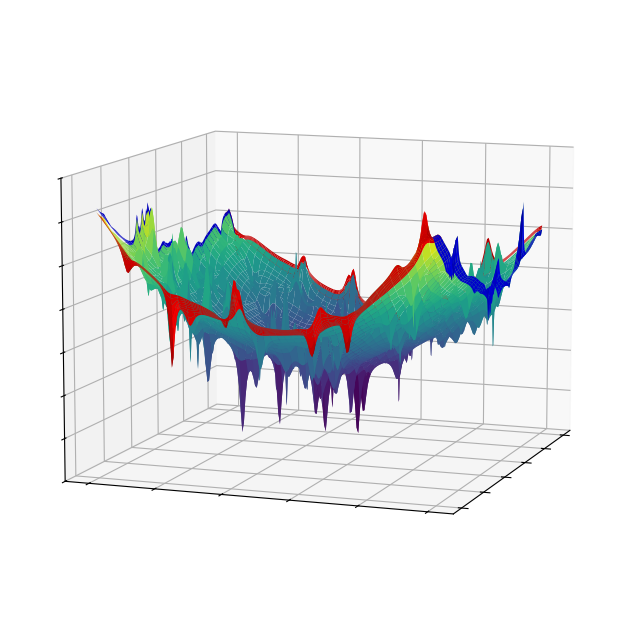

In [7]:
plot3D(surface[150:350, 150:400])

In [8]:
# Filtering persitent 0-homology
tf3D_0 = ta.ImageFilter(surface)
surface_0 = tf3D_0.low_pers_filter(1e+5) #Filtering all finite persistence

#Filtering persitent 1-homology
tf3D_1 = ta.ImageFilter(surface_0, dual=True)
surface_filtered = tf3D_1.low_pers_filter(1e+5)

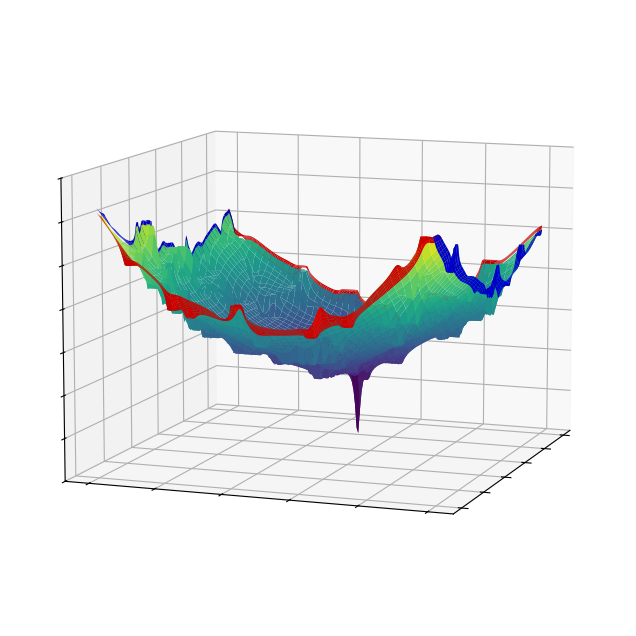

In [9]:
plot3D(surface_filtered[150:350, 150:400])

# Example V.3 (Natural image)

In [10]:
import topapprox as ta
import cripser
import persim
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import sys,os

import warnings
warnings.filterwarnings("ignore")

In [11]:
# download image
download_url = "https://github.com/mvlier/topapprox/raw/main/notebook/pagoda.npy"
fn = "pagoda.npy"
if not os.path.isfile(fn):
    urllib.request.urlretrieve(download_url, fn)

img = np.load(fn)

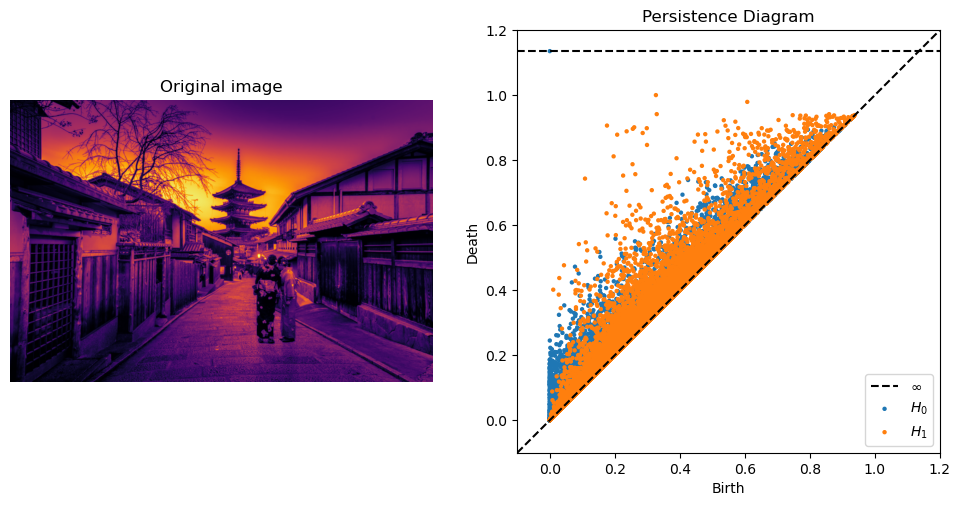

In [12]:
# Plotting original image with its persistence diagram
fig, ax = plt.subplots(1,2, figsize=(12,24))
ax[0].imshow(img, cmap='inferno')
ax[0].axis('off')
ax[0].title.set_text('Original image')
PD = cripser.computePH(img)
PD = [PD[PD[:,0]==i,1:3] for i in range(2)]
persim.plot_diagrams(PD,size=10,ax=ax[1],xy_range = [-0.1,1.2,-0.1,1.2])
ax[1].title.set_text('Persistence Diagram')

In [13]:
# Filtering image by a threshold of 0.0704
e1 = 0.0704

# Filtering persitent 0-homology
tf_imga_0 = ta.ImageFilter(img)
img_1 = tf_imga_0.low_pers_filter(e1)

#Filtering persitent 1-homology
tf_imga_1 = ta.ImageFilter(img_1, dual=True)
imga = tf_imga_1.low_pers_filter(e1)


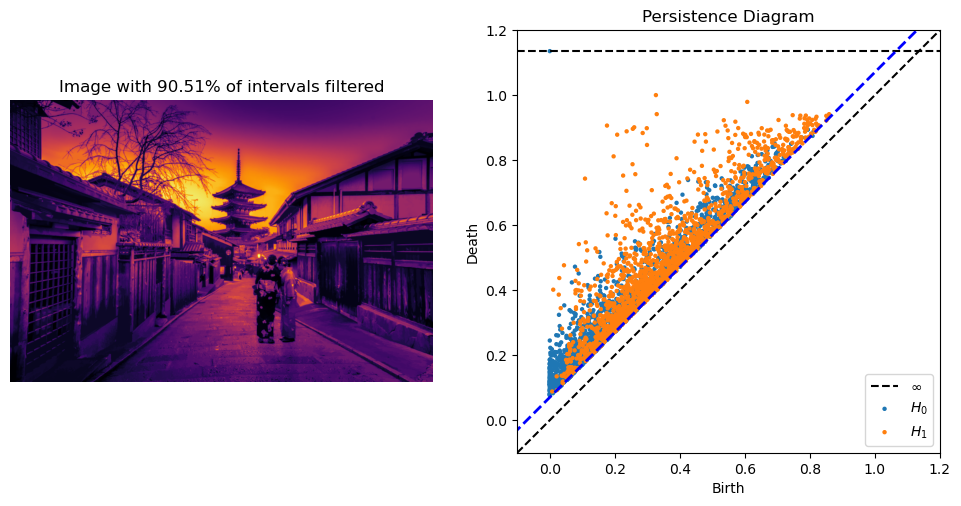

In [14]:
# Plotting original image with its persistence diagram
fig, ax = plt.subplots(1,2, figsize=(12,24))
ax[0].imshow(imga, cmap='inferno')
ax[0].axis('off')
ax[0].title.set_text('Image with 90.51% of intervals filtered')
PDa = cripser.computePH(imga)
PDa = [PDa[PDa[:,0]==i,1:3] for i in range(2)]
persim.plot_diagrams(PDa,size=10,ax=ax[1],xy_range = [-0.1,1.2,-0.1,1.2])
ax[1].title.set_text('Persistence Diagram')
ax[1].plot([-100,100], [-100+e1,100+e1], '--', linewidth=2.0, c="b")

In [15]:
percentage_filtered_a = (1 - (PDa[0].size + PDa[1].size) / (PD[0].size + PD[1].size)) * 100
print(f'The exact percentage of filtered intervals in the case above is {percentage_filtered_a}')

The exact percentage of filtered intervals in the case above is 90.50826554087708


In [16]:
# Filtering image by a threshold of 0.3022
e2 = 0.3022

# Filtering persitent 0-homology
tf_imgb_0 = ta.ImageFilter(img)
imgb_1 = tf_imgb_0.low_pers_filter(e2)

#Filtering persitent 1-homology
tf_imgb_1 = ta.ImageFilter(imgb_1, dual=True)
imgb = tf_imgb_1.low_pers_filter(e2)

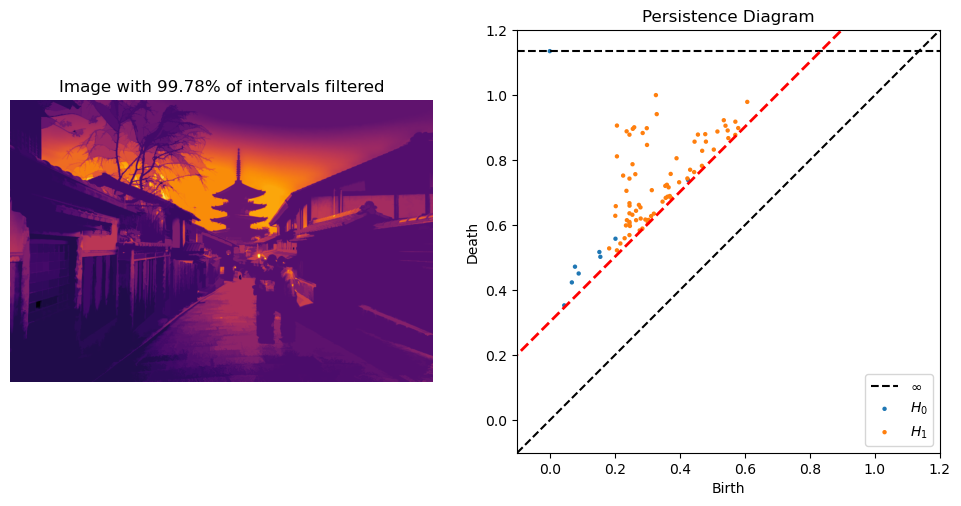

In [17]:
# Plotting original image with its persistence diagram
fig, ax = plt.subplots(1,2, figsize=(12,24))
ax[0].imshow(imgb, cmap='inferno')
ax[0].axis('off')
ax[0].title.set_text('Image with 99.78% of intervals filtered')
PDb = cripser.computePH(imgb)
PDb = [PDb[PDb[:,0]==i,1:3] for i in range(2)]
persim.plot_diagrams(PDb, size=10,ax=ax[1],xy_range = [-0.1,1.2,-0.1,1.2])
ax[1].title.set_text('Persistence Diagram')
ax[1].plot([-100,100], [-100+e2,100+e2], '--', linewidth=2.0, c="r")

In [18]:
percentage_filtered_b = (1 - (PDb[0].size + PDb[1].size) / (PD[0].size + PD[1].size)) * 100
print(f'The exact percentage of filtered intervals in the case above is {percentage_filtered_b}')

The exact percentage of filtered intervals in the case above is 99.79840144202262


# Example V.4 (Signal over a mesh)

In [19]:
import topapprox as ta
import cripser
import persim
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import sys,os

import warnings
warnings.filterwarnings("ignore")

import plotly.graph_objects as go
import csv

In [49]:
# load mesh data
download_url = "https://github.com/mvlier/topapprox/raw/main/notebook/mesh.ply"
fn = 'mesh.ply'
if not os.path.isfile(fn):
    urllib.request.urlretrieve(download_url, fn)

# read the PLY back and restore V, F in the original shapes
with open(fn, "r") as fh:
    # parse header
    line = fh.readline()
    if not line.startswith("ply"):
        raise ValueError("Not a PLY file")
    vertex_count = 0
    face_count = 0
    while True:
        line = fh.readline()
        if line.startswith("element vertex"):
            vertex_count = int(line.split()[-1])
        elif line.startswith("element face"):
            face_count = int(line.split()[-1])
        elif line.strip() == "end_header":
            break

    verts_read = []
    for _ in range(vertex_count):
        parts = fh.readline().strip().split()
        verts_read.append([float(parts[0]), float(parts[1]), float(parts[2])])
    faces_read = []
    for _ in range(face_count):
        parts = fh.readline().strip().split()
        # parts[0] is the count (should be 3)
        faces_read.append([int(parts[1]), int(parts[2]), int(parts[3])])

V= np.array(verts_read).T
F = np.array(faces_read).T

print(f"mesh loaded from {fn}. V.shape={V.shape}, F.shape={F.shape}")

mesh loaded from mesh.ply. V.shape=(3, 2002), F.shape=(3, 3998)


In [50]:
# load signal data
download_url = "https://github.com/mvlier/topapprox/raw/main/notebook/func.csv"
fn = 'func.csv'
if not os.path.isfile(fn):
    urllib.request.urlretrieve(download_url, fn)

# Open the CSV file
with open(fn, newline='') as csvfile:
    csvreader = csv.reader(csvfile)
    func_ = list(csvreader)


# Eliminate header and change format, from list to dictionary
func_ = func_[1:]
func_dict = {int(x[0]):float(x[1]) for x in func_}
func_array = np.array(sorted(func_dict.items()))[:,1]

cmin = min(func_dict.values())
cmax = max(func_dict.values())


In [51]:
def plot_mesh(v, f, func, cmin, cmax):
    data = go.Mesh3d(
            #Vertices
            x=v[0],
            y=v[1],
            z=v[2],
            #colorbar_title='z',
            colorscale=[[0, '#440154'],
                        [0.24, '#481a6c'],
                        [0.35, '#3b528b'],
                        [0.5, '#21918c'],
                        [0.65, '#5ec962'],
                        [0.8, '#d2e21b'],
                        [1, '#fde725']],
            #colorscale = 'bluered',
            cmin = cmin,
            cmax = cmax,
            # Intensity of each vertex, which will be interpolated and color-coded
            intensity=func,
            #Faces
            i=f[0],
            j=f[1],
            k=f[2],
            name='y',
            showscale=True,
            colorbar=dict(
                x=0.85,  # Adjust the color bar position closer to the plot
                thickness=20,
                len = 0.8
            )
        )

    fig = go.Figure(data = [data])

    a = 1.17

    fig.update_layout(
        scene_camera=dict(
            eye=dict(x=-1*a, y=-1*a, z=0.5*a)
        )
    )

    fig.update_layout(
        scene=dict(
            xaxis=dict(showticklabels=False, title=''),
            yaxis=dict(showticklabels=False, title=''),
            zaxis=dict(showticklabels=False, title=''),
        )
    )

    fig.update_layout(scene = dict(xaxis = dict(showgrid = False),
                                    yaxis = dict(showgrid = False),
                                    zaxis = dict(showgrid = False)
                ))
    fig.update_scenes(xaxis_visible=False, yaxis_visible=False,zaxis_visible=False )

    return fig

Original scalar field over mesh

In [53]:
import kaleido
fig = plot_mesh(V, F, func_array, cmin, cmax)
# This produces a png image
#fig.show(renderer="png")
# This produces an interactive plot
fig.show()

In [54]:
faces = np.array([[F[0][i],F[1][i],F[2][i]] for i in range(F[0].size)])
signal = np.array([value for key, value in func_dict.items()])

eps = 0.2
tfg = ta.GraphFilter()
tfg.compute_gwf(faces, [], signal)
filtered_0 = tfg.low_pers_filter(epsilon = eps)
# filtered_0 = tfg.get_modified_filtration()

Filtered Scalar Fields - after filtering only persistent 0-homology below the threshold eps=0.2


In [55]:
fig2 = plot_mesh(V, F, filtered_0, cmin, cmax)
# This produces an png image
#fig2.show(renderer="png")
# This produces an interactive plot
fig2.show()


In [56]:
eps = 0.2
tfgd = ta.GraphFilter(dual=True)
tfgd.compute_gwf(faces, [], filtered_0)
filtered_01 = tfgd.low_pers_filter(epsilon = eps)
# _ = tfgd.compute(epsilon = eps, dual=True)=True
# filtered_01 = tfgd.get_modified_filtration()

Filtered Scalar Fields - after filtering both persistent 0- and 1-homology below the threshold eps=0.2


In [58]:
fig3 = plot_mesh(V, F, filtered_01, cmin, cmax)
# This produces a png image
#fig3.show(renderer="png")
# This produces an interactive plot
fig3.show()

### Plotting persistence diagrams for the three scalar fields over the mesh

In [32]:
# Import function for computing persistence diagram of a graph with faces
from topapprox.persistence import get_PD_gwf

In [33]:
PD_original = get_PD_gwf(faces, [], signal)
PD_0 = get_PD_gwf(faces, [], filtered_0)
PD_01 = get_PD_gwf(faces, [], filtered_01)

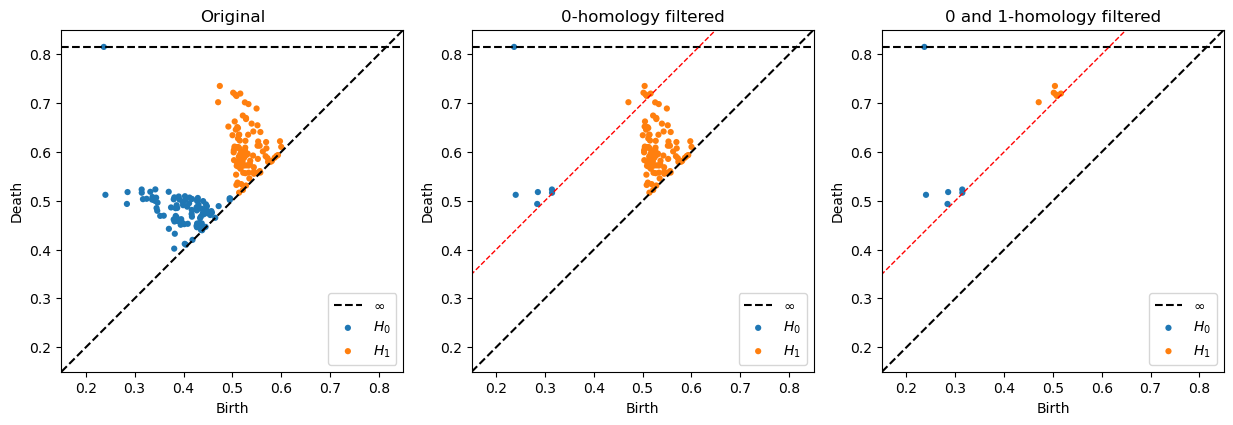

In [34]:
fig, ax = plt.subplots(1, 3, figsize=(15,6))
persim.plot_diagrams(PD_original, ax=ax[0], xy_range = [0.15, 0.85, 0.15, 0.85])
persim.plot_diagrams(PD_0, ax=ax[1], xy_range = [0.15, 0.85, 0.15, 0.85])
persim.plot_diagrams(PD_01, ax=ax[2], xy_range = [0.15, 0.85, 0.15, 0.85])
ax[1].plot([-100,100], [-100+eps,100+eps], '--', linewidth=1.0, c="r")
ax[2].plot([-100,100], [-100+eps,100+eps], '--', linewidth=1.0, c="r")
ax[0].title.set_text('Original')
ax[1].title.set_text('0-homology filtered')
ax[2].title.set_text('0 and 1-homology filtered')

# Example: Filter Comparison (LPF vs FFT low-pass, 1D)

# Low-persistence filtering vs. FFT low-pass filtering (1D)

This notebook builds a minimal 1D signal that cleanly separates **persistence-based
filtering** (LPF, the topological filter implemented in `topapprox`) from classical
**FFT low-pass filtering**.

The signal is the sum of three ingredients:

| component | what it is | frequency | amplitude / persistence | we want to |
|---|---|---|---|---|
| **sharp peaks** | two narrow triangular spikes | **high** (broadband) | **large** (tall) | **keep** |
| **ripple** | a slow sinusoid | **low** | small | remove |
| **noise** | aperiodic broadband noise | all | small | remove |

The two filters select features along *different axes*:

* **FFT low-pass keeps low frequencies and discards high ones.**
  A single cutoff therefore faces a dilemma — it can never both remove the small
  stuff *and* keep the sharp peaks:
  * a *low* cutoff suppresses the broadband noise but **destroys the sharp peaks**
    (a narrow spike is built almost entirely from high frequencies) and leaves
    visible Gibbs ringing;
  * a *high* cutoff preserves the peaks but **leaves the noise** in;
  * **the low-frequency ripple survives either way** — it sits below any useful cutoff.

* **Low-persistence filtering keeps high-persistence (tall) features and discards
  low-persistence (small) ones, regardless of their frequency content.**
  It removes the broadband noise, collapses the small ripple, and **preserves the
  sharp peaks exactly**, while staying within `epsilon` of the input in the
  $L^\infty$ norm.


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import topapprox as ta

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# colours used throughout
C_IN, C_TGT, C_LPF, C_FLO, C_FHI = "0.35", "#2ca02c", "#1f77b4", "#d62728", "#ff7f0e"


## 1. Construct the signal

`peaks` is the ground-truth signal we want to recover. The full input adds a
low-frequency ripple and broadband noise on top of it.

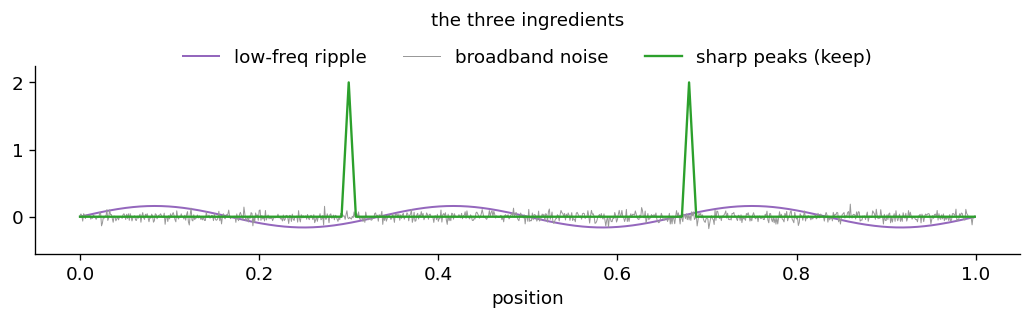

In [36]:
N = 1000
t = np.linspace(0.0, 1.0, N, endpoint=False)

def triangle(t, center, halfwidth, height):
    # a narrow triangular spike -- sharp, hence broadband in frequency
    d = np.abs(t - center)
    return np.where(d < halfwidth, height * (1.0 - d / halfwidth), 0.0)

# (c) features to KEEP: two tall, sharp triangular peaks
peaks = triangle(t, 0.30, 0.008, 2.0) + triangle(t, 0.68, 0.008, 2.0)

# (a) low-frequency small ripple -> want REMOVED (persistence ~ 2*0.16 = 0.32)
ripple = 0.16 * np.sin(2 * np.pi * 3 * t)

# (b) aperiodic broadband noise  -> want REMOVED
rng = np.random.default_rng(1)
noise = 0.05 * rng.standard_normal(N)

signal = peaks + ripple + noise

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(t, ripple, lw=1.2, color="#9467bd", label="low-freq ripple")
ax.plot(t, noise, lw=0.6, color="0.6", label="broadband noise")
ax.plot(t, peaks, lw=1.4, color=C_TGT, label="sharp peaks (keep)")
ax.set_title("the three ingredients", pad=24); ax.set_xlabel("position")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.18))
ax.set_ylim(-0.55, 2.25)
fig.tight_layout()


## 2. Apply the two filters

**Low-persistence filter.** `iteration_order="01"` removes low-persistence
features of the sub-level filtration (shallow basins / dips, `0`) and then of the
super-level filtration (small peaks, `1`); together this removes every topological
feature whose persistence is below `epsilon`, from both directions.

**FFT low-pass.** An ideal (brick-wall) low-pass keeping the lowest `keep`
frequency bins. We show two cutoffs to expose the dilemma.

In [37]:
epsilon = 0.4
lpf = (ta.PersistenceFilter()
         .load_signal(signal)
         .low_pers_filter(epsilon, iteration_order="01", method="python"))

def fft_lowpass(sig, keep):
    # ideal brick-wall low-pass: keep the lowest `keep` rfft bins, zero the rest
    F = np.fft.rfft(sig)
    F[keep:] = 0.0
    return np.fft.irfft(F, n=len(sig))

# cutoff = number of retained cycles-per-domain.  Ripple lives at 3 cycles,
# so it survives both cutoffs; the sharp peaks need many high harmonics.
CUT_LOW, CUT_HIGH = 10, 70          # "remove noise" vs "keep peaks"
fft_low  = fft_lowpass(signal, CUT_LOW)
fft_high = fft_lowpass(signal, CUT_HIGH)

# sanity check: the L-infinity guarantee of the topological filter
print(f"max|LPF - input| = {np.abs(lpf - signal).max():.3f}  (<= epsilon = {epsilon})")


max|LPF - input| = 0.383  (<= epsilon = 0.4)


## 3. The comparison figure

Shaded band = the $\pm\varepsilon$ "sub-threshold zone": features that stay inside it
are removed, features that stick out of it (the peaks) are kept. The insets zoom on
the right-hand peak.

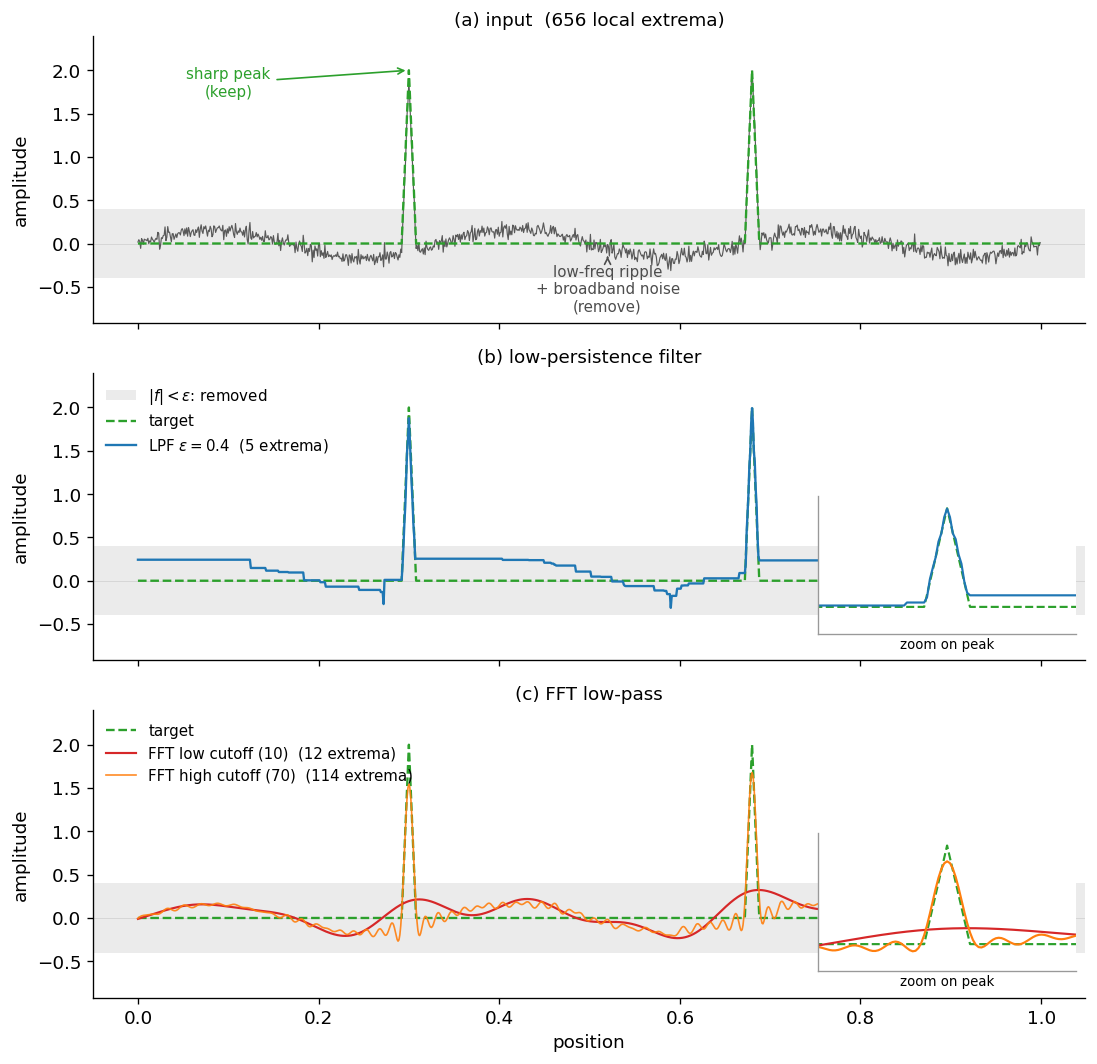

In [38]:
def n_extrema(y):
    s = np.sign(np.diff(y)); s = s[s != 0]
    return int(np.sum(s[1:] != s[:-1]))

ZX, ZY = (0.635, 0.725), (-0.55, 2.25)   # zoom window on the right peak
fig, axs = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

# (a) input
axs[0].axhspan(-epsilon, epsilon, color="0.85", alpha=0.5, lw=0)
axs[0].plot(t, signal, lw=0.7, color=C_IN)
axs[0].plot(t, peaks, lw=1.4, color=C_TGT, ls="--")
axs[0].set_title(f"(a) input  ({n_extrema(signal)} local extrema)")
axs[0].annotate("sharp peak\n(keep)", xy=(0.30, 2.0), xytext=(0.10, 1.7),
                fontsize=9, color=C_TGT, ha="center",
                arrowprops=dict(arrowstyle="->", color=C_TGT, lw=1))
axs[0].annotate("low-freq ripple\n+ broadband noise\n(remove)", xy=(0.52, -0.15),
                xytext=(0.52, -0.78), fontsize=9, color="0.3", ha="center",
                arrowprops=dict(arrowstyle="->", color="0.3", lw=1))

# (b) low-persistence filter
axs[1].axhspan(-epsilon, epsilon, color="0.85", alpha=0.5, lw=0,
               label=r"$|f|<\varepsilon$: removed")
axs[1].plot(t, peaks, lw=1.4, color=C_TGT, ls="--", label="target")
axs[1].plot(t, lpf, lw=1.4, color=C_LPF, label=f"LPF $\\varepsilon={epsilon}$  ({n_extrema(lpf)} extrema)")
axs[1].set_title("(b) low-persistence filter")
axs[1].legend(loc="upper left", ncol=1, fontsize=9)

# (c) FFT low-pass
axs[2].axhspan(-epsilon, epsilon, color="0.85", alpha=0.5, lw=0)
axs[2].plot(t, peaks, lw=1.4, color=C_TGT, ls="--", label="target")
axs[2].plot(t, fft_low,  lw=1.3, color=C_FLO, label=f"FFT low cutoff ({CUT_LOW})  ({n_extrema(fft_low)} extrema)")
axs[2].plot(t, fft_high, lw=1.0, color=C_FHI, alpha=0.9, label=f"FFT high cutoff ({CUT_HIGH})  ({n_extrema(fft_high)} extrema)")
axs[2].set_title("(c) FFT low-pass")
axs[2].legend(loc="upper left", ncol=1, fontsize=9)

for ax in axs:
    ax.axhline(0, color="0.8", lw=0.5, zorder=0)
    ax.set_ylim(-0.92, 2.4); ax.set_ylabel("amplitude")
axs[2].set_xlabel("position")
fig.tight_layout()

# zoom insets are added AFTER tight_layout (they are not tight_layout-compatible)
for ax, curves in [
        (axs[1], [(peaks, C_TGT, "--"), (lpf, C_LPF, "-")]),
        (axs[2], [(peaks, C_TGT, "--"), (fft_low, C_FLO, "-"), (fft_high, C_FHI, "-")])]:
    ai = inset_axes(ax, width="26%", height="48%", loc="lower right",
                    bbox_to_anchor=(0, 0.06, 1, 1), bbox_transform=ax.transAxes)
    for y, c, ls in curves:
        ai.plot(t, y, color=c, ls=ls, lw=1.3)
    ai.set_xlim(*ZX); ai.set_ylim(*ZY); ai.set_xticks([]); ai.set_yticks([])
    ai.tick_params(length=0)
    ai.set_xlabel("zoom on peak", fontsize=8, labelpad=2)
    for s in ai.spines.values():
        s.set_edgecolor("0.6")

import os; os.makedirs("figures", exist_ok=True)
fig.savefig("figures/filter_comparison.pdf", bbox_inches="tight")
fig.savefig("figures/filter_comparison.png", bbox_inches="tight")


## 4. Why FFT cannot win — the frequency picture

A narrow spike is **broadband**: its energy is spread over *all* frequencies,
overlapping the noise floor. The ripple is a single low-frequency line.

* To erase the noise you must cut at a **low** frequency — but that also throws
  away most of the peaks' energy (low cutoff, red).
* To keep the peaks you must retain **high** frequencies — but that also keeps the
  noise (high cutoff, orange).
* **No vertical cutoff line separates "peak energy" from "noise energy"**, and the
  ripple sits to the left of both cutoffs, so it always survives.

Persistence filtering instead thresholds *horizontally* (by amplitude / prominence),
which is exactly the separation we want.

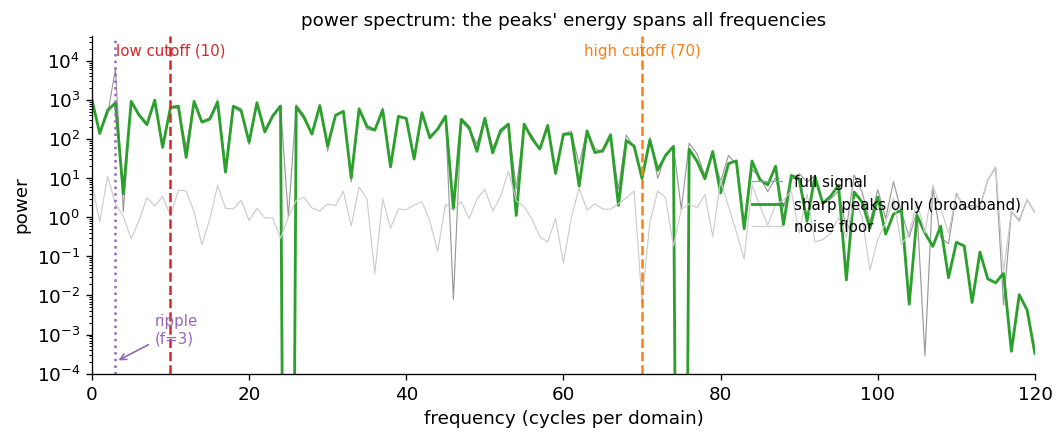

In [39]:
freq = np.fft.rfftfreq(N, d=1.0 / N)        # cycles per domain
P_sig   = np.abs(np.fft.rfft(signal))**2
P_peaks = np.abs(np.fft.rfft(peaks))**2
P_noise = np.abs(np.fft.rfft(noise))**2

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.semilogy(freq, P_sig,   lw=0.7, color="0.6",  label="full signal")
ax.semilogy(freq, P_peaks, lw=1.7, color=C_TGT, label="sharp peaks only (broadband)")
ax.semilogy(freq, P_noise, lw=0.7, color="0.8", label="noise floor")
ax.axvline(3, color="#9467bd", ls=":", lw=1.5)
ax.annotate("ripple\n(f=3)", xy=(3, 2e-4), xytext=(8, 6e-4), color="#9467bd",
            fontsize=9, arrowprops=dict(arrowstyle="->", color="#9467bd", lw=1))
for cut, c, name in [(CUT_LOW, C_FLO, "low cutoff"), (CUT_HIGH, C_FHI, "high cutoff")]:
    ax.axvline(cut, color=c, ls="--", lw=1.5)
    ax.text(cut, P_sig.max()*2.2, f"{name} ({cut})", color=c, fontsize=9, ha="center")
ax.set_xlim(0, 120); ax.set_ylim(1e-4, P_sig.max()*7)
ax.set_xlabel("frequency (cycles per domain)"); ax.set_ylabel("power")
ax.set_title("power spectrum: the peaks' energy spans all frequencies")
ax.legend(loc="center right", fontsize=9)
fig.tight_layout()
fig.savefig("figures/filter_comparison_spectrum.pdf", bbox_inches="tight")
fig.savefig("figures/filter_comparison_spectrum.png", bbox_inches="tight")


## 5. Quantitative summary

Three numbers per method:

* **peak height** — how well the tall sharp feature is preserved (target = 2.0);
* **# local extrema** — signal complexity / how much spurious oscillation remains
  (FFT ringing *adds* extrema; LPF collapses them);
* **max $|f_{\text{out}}-f_{\text{in}}|$** — the largest change the filter makes to the
  signal. LPF is *provably* bounded by $\varepsilon$; FFT is not — its low cutoff
  changes the signal by $\approx$ the full peak height, i.e. it deletes a *real*
  feature.

(A global RMSE-to-target is deliberately omitted: it is dominated by the small,
bounded DC-level shift that LPF is allowed to leave behind, and so hides the
qualitative difference the eye sees in the figure.)

In [40]:
def peak_height(y):
    return max(y[np.abs(t - 0.30) < 0.012].max(), y[np.abs(t - 0.68) < 0.012].max())

def max_change(y):
    return float(np.abs(y - signal).max())

rows = [
    ("LPF (eps=0.4)",              lpf),
    (f"FFT low cut ({CUT_LOW})",   fft_low),
    (f"FFT high cut ({CUT_HIGH})", fft_high),
]
print(f"{'method':<22}{'peak height':>13}{'# extrema':>12}{'max|out-in|':>13}")
print(f"{'(target / input)':<22}{2.0:>13.2f}{n_extrema(peaks):>12d}{0.0:>13.2f}")
print("-" * 60)
for name, y in rows:
    print(f"{name:<22}{peak_height(y):>13.2f}{n_extrema(y):>12d}{max_change(y):>13.2f}")


method                  peak height   # extrema  max|out-in|
(target / input)               2.00           3         0.00
------------------------------------------------------------
LPF (eps=0.4)                  1.99           5         0.38
FFT low cut (10)               0.32          12         1.68
FFT high cut (70)              1.68         114         0.33


## Conclusion

* **LPF** preserves the sharp peaks essentially exactly (height $\approx 2.0$),
  collapses 600+ extrema down to a handful, and stays within $\varepsilon$ of the
  input — all without ever looking at frequency.
* **FFT low-pass** is trapped: the low cutoff flattens the peaks to a fraction of
  their height (and the ripple still gets through), while the high cutoff keeps the
  peaks only at the price of conspicuous Gibbs ringing and unremoved noise.

A smooth low-pass (Gaussian / Butterworth) removes the ringing but not the dilemma:
it still attenuates and broadens the sharp peaks and still passes the low-frequency
ripple. The separation we want — *small features out, sharp features in* — is a
statement about amplitude / persistence, not frequency, which is exactly what the
topological filter delivers.
